In [ ]:
import pandas as pd
import numpy as np

# text preprocessing
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
import re, string, nltk
from nltk.stem import WordNetLemmatizer
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# plots and metrics
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# feature extraction / vectorization
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# classifiers
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

# save and load a file
import pickle

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
train_data = pd.read_csv(r'data_train.csv')
train_data.head()

,Emotion,Text
0,neutral,There are tons of other paintings that I thin...
1,sadness,"Yet the dog had grown old and less capable , a..."
2,fear,When I get into the tube or the train without ...
3,fear,This last may be a source of considerable disq...
4,anger,She disliked the intimacy he showed towards so...


In [ ]:
test_data = pd.read_csv('data_test.csv')
test_data.head()

,Emotion,Text
0,sadness,I experienced this emotion when my grandfather...
1,neutral,"when I first moved in , I walked everywhere ...."
2,anger,"` Oh ! "" she bleated , her voice high and rath..."
3,fear,"However , does the right hon. Gentleman recogn..."
4,sadness,My boyfriend didn't turn up after promising th...


In [ ]:
train_data.iloc[0]

,0
Emotion,neutral
Text,There are tons of other paintings that I thin...


In [ ]:
X_train = train_data.Text
X_test = test_data.Text

y_train = train_data.Emotion
y_test = test_data.Emotion

class_names = list(train_data.Emotion.unique())
data = pd.concat([train_data, test_data])

print("size of the training set", len(train_data.Text))
print("size of the validation set", len(test_data.Text))
print(data.Emotion.value_counts())

data.head()

size of the training set 7934
size of the validation set 3393
Emotion
joy        2326
sadness    2317
anger      2259
neutral    2254
fear       2171
Name: count, dtype: int64


,Emotion,Text
0,neutral,There are tons of other paintings that I thin...
1,sadness,"Yet the dog had grown old and less capable , a..."
2,fear,When I get into the tube or the train without ...
3,fear,This last may be a source of considerable disq...
4,anger,She disliked the intimacy he showed towards so...


In [ ]:
def plot_confusion_matrix(y_true, y_pred, classes,
                          normalize=False,
                          title=None,
                          cmap=plt.cm.Blues):
    '''
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    '''
    if not title:
        if normalize:
            title = 'Normalized confusion matrix'
        else:
            title = 'Confusion matrix, without normalization'

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    fig, ax = plt.subplots()

    # Set size
    fig.set_size_inches(12.5, 7.5)
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)
    ax.grid(False)

    # We want to show all ticks...
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           # ... and label them with the respective list entries
           xticklabels=classes, yticklabels=classes,
           title=title,
           ylabel='True label',
           xlabel='Predicted label')

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")

    # Loop over data dimensions and create text annotations.
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    fig.tight_layout()
    return ax

# 2. Text Preprocessing
Here are some preprocessing steps to consider:

- Removing noise: html markups, urls, non-ascii symbols, trailing whitespace etc.
- Removing punctuation
- Normalizing emoticons
- Negation handling
- Tokenization: split text into word tokens
- Stopword removal
- Stemming or lemmatization


 However, most of these steps did not improve our classification results. Since our data was mostly taken from written dialogs it was almost ready to use.

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def text_preprocessing(text):
    # 1. Clean
    text = text.lower() # lowercasing
    text = re.sub(r'http\S+', '', text) # Remove URLs
    text = text.translate(str.maketrans('', '', string.punctuation)) # Remove punctuation
    text = re.sub(r'\d+', '', text) # Remove numbers
    text = ' '.join(text.split()) # Fix extra spaces

    # 2. Tokenize
    tokens = word_tokenize(text)

    # 3. Remove stop words
    tokens = [t for t in tokens if t not in stop_words]

    #  4. Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return tokens

raw = "The users are RUNNING apps!! Check https://x.com"
result = text_preprocessing(raw)
print(result)

['user', 'running', 'apps', 'check']


# 3. Text Representation
Vectorizing text using Term Frequency technique (Term Frequency(TF) — Inverse Dense Frequency(IDF))


- Tekenize with our preprocess_and_tokenize
- Find it’s TF = (Number of repetitions of word in a document) / (# of words in a document)
- IDF = log(# of documents / # of documents containing the word)

In [ ]:
# TFIDF, unigrams and bigrams
vector = TfidfVectorizer(tokenizer=text_preprocessing, sublinear_tf=True, norm='l2', ngram_range=(1, 2))

# fit on our complete corpus
vector.fit(X_train)

# transform testing and training datasets to vectors
X_train_vect = vector.transform(X_train)
X_test_vect = vector.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [ ]:
print(X_test_vect.shape)
print(X_test_vect[0])

(3393, 52485)
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 7 stored elements and shape (1, 52485)>
  Coords	Values
  (0, 3156)	0.2849703526521431
  (0, 13125)	0.39336085712412966
  (0, 14462)	0.39061256859013704
  (0, 19728)	0.3543167489287381
  (0, 19741)	0.5230625770782228
  (0, 33284)	0.29290467453551144
  (0, 33286)	0.3557428691841941


In [ ]:
df = pd.DataFrame(
    X_test_vect[0].toarray(),
    columns=vector.get_feature_names_out()
)

print(df.T.sort_values(by=0, ascending=False).head(10))

                             0
grandfather passed    0.523063
emotion               0.393361
experienced           0.390613
passed away           0.355743
grandfather           0.354317
passed                0.292905
away                  0.284970
preparation           0.000000
preparation began     0.000000
preparation vologsky  0.000000


# 4. Classifiers

### Naive Bayes

Accuracy: 64.13%

F1 Score: 64.13

COnfusion Matrix:
 [[448  50  53  34 108]
 [ 65 450  62  21  81]
 [ 38  18 487  89  75]
 [ 56  25  74 285 198]
 [ 72  23  50  25 506]]


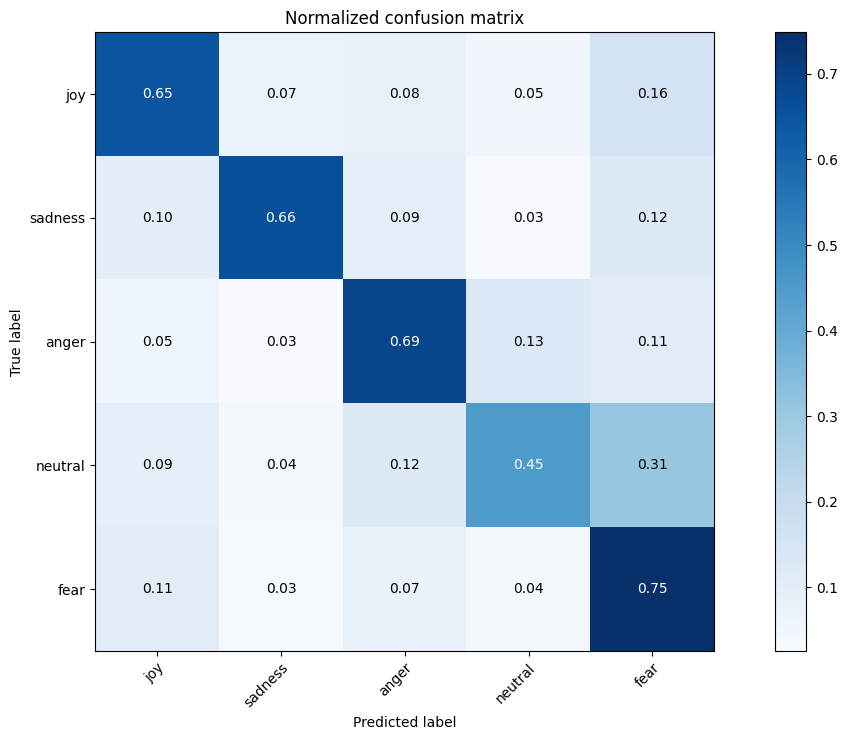

In [ ]:
nb = MultinomialNB()

nb.fit(X_train_vect, y_train)

ynb_pred = nb.predict(X_test_vect)

print("Accuracy: {:.2f}%".format(accuracy_score(y_test, ynb_pred) * 100))
print("\nF1 Score: {:.2f}".format(f1_score(y_test, ynb_pred, average='micro') * 100))
print("\nCOnfusion Matrix:\n", confusion_matrix(y_test, ynb_pred))

# Plot normalized confusion matrix
plot_confusion_matrix(y_test, ynb_pred, classes=class_names, normalize=True, title='Normalized confusion matrix')
plt.show()

### Linear Support Vector

Accuracy: 70.50%

F1 Score: 70.50

COnfusion Matrix:
 [[469  53  40  59  72]
 [ 58 506  36  39  40]
 [ 41  33 488  99  46]
 [ 46  32  57 458  45]
 [ 71  39  53  42 471]]


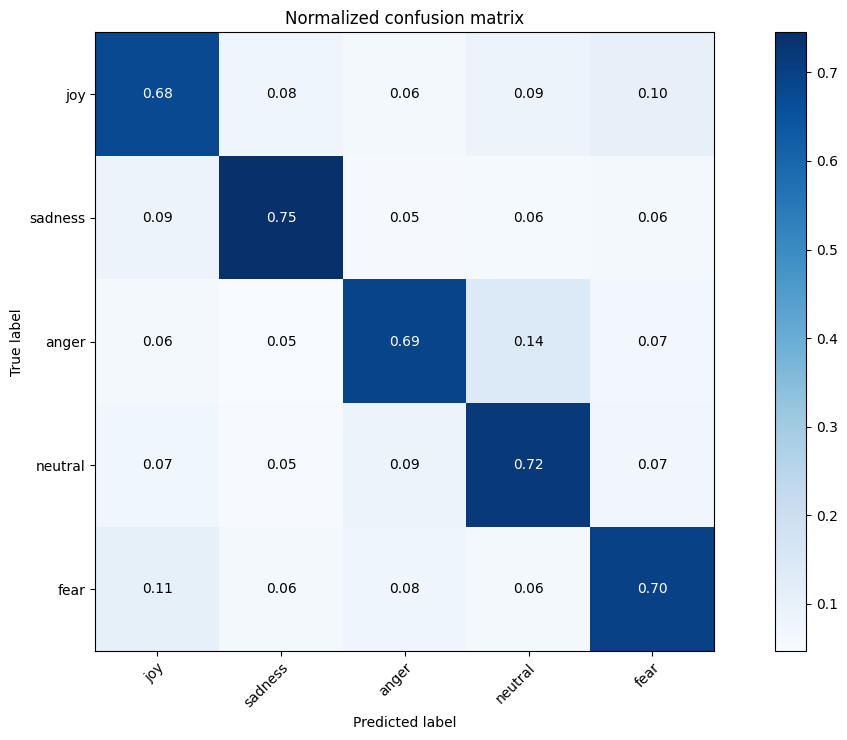

In [ ]:
svc = LinearSVC(tol=1e-05)
svc.fit(X_train_vect, y_train)

ysvm_pred = svc.predict(X_test_vect)

print("Accuracy: {:.2f}%".format(accuracy_score(y_test, ysvm_pred) * 100))
print("\nF1 Score: {:.2f}".format(f1_score(y_test, ysvm_pred, average='micro') * 100))
print("\nCOnfusion Matrix:\n", confusion_matrix(y_test, ysvm_pred))

plot_confusion_matrix(y_test, ysvm_pred, classes=class_names, normalize=True, title='Normalized confusion matrix')
plt.show()

## Logistic Regression

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 68.91%

F1 Score: 68.91

COnfusion Matrix:
 [[470  59  45  57  62]
 [ 68 495  39  39  38]
 [ 50  30 474 115  38]
 [ 55  31  66 438  48]
 [ 83  40  53  39 461]]


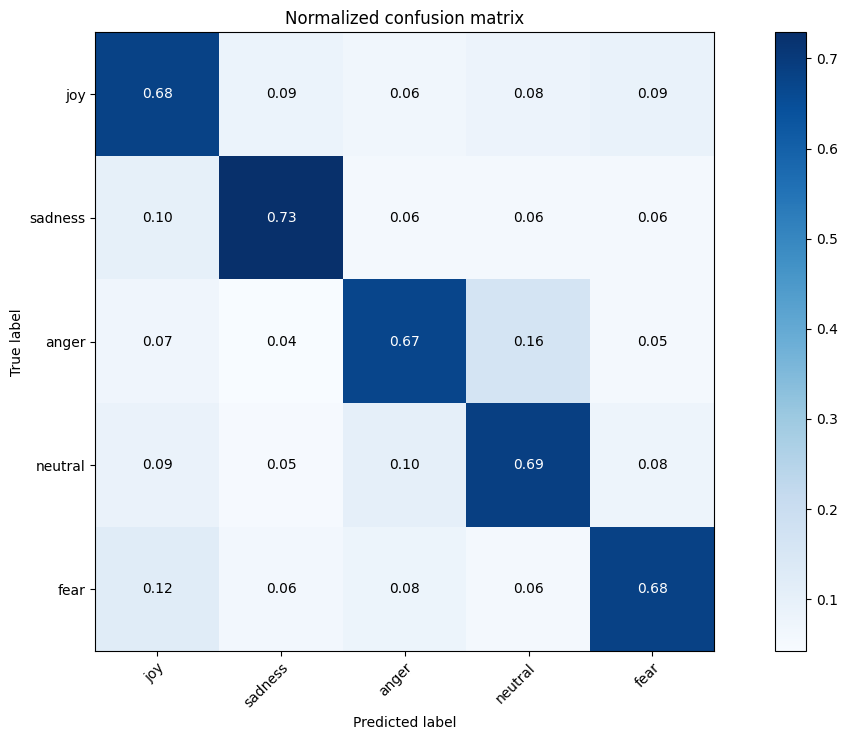

In [ ]:
log = LogisticRegression(solver='lbfgs', multi_class='auto', max_iter=200)
log.fit(X_train_vect, y_train)

ylog_pred = log.predict(X_test_vect)

print("Accuracy: {:.2f}%".format(accuracy_score(y_test, ylog_pred) * 100))
print("\nF1 Score: {:.2f}".format(f1_score(y_test, ylog_pred, average='micro') * 100))
print("\nCOnfusion Matrix:\n", confusion_matrix(y_test, ylog_pred))

plot_confusion_matrix(y_test, ylog_pred, classes=class_names, normalize=True, title='Normalized confusion matrix')
plt.show()